# Model Selection and Non-Identifiability (Julia)

Self-contained demo: (1) how AIC/BIC penalize overly flexible polynomial models, and (2) how a higher-order product-only dependence yields non-unique parameter sets with nearly identical fits.

In [ ]:
using Random
using Statistics
using LinearAlgebra
using Plots

Random.seed!(42)

## 0. Setup and data generation
Generate noisy linear data `y = 2 + 3x + ?` on `x ? [0, 1]` to serve as the ground truth for model selection.

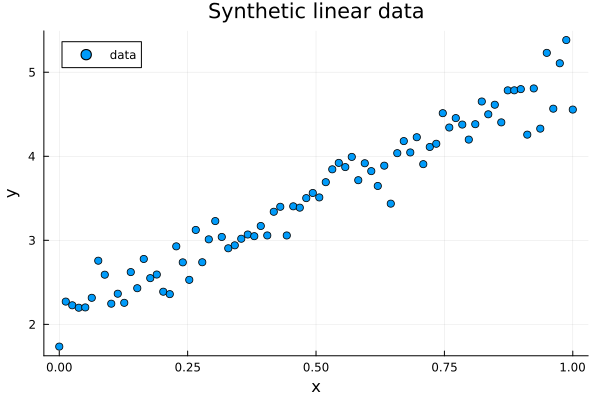

In [39]:
n_points = 80
x_data = collect(range(0, 1, length = n_points))
sigma = 0.2
noise = randn(n_points) .* sigma
y_data = 2.0 .+ 3.0 .* x_data .+ noise

scatter(x_data, y_data; xlabel = "x", ylabel = "y", label = "data", title = "Synthetic linear data")

## 1. Polynomial regression models and BIC
Fit polynomials of degrees 1?8, compute SSE, AIC, and BIC, and see where the penalties outweigh small fit improvements.

In [40]:
# Design matrix with columns [1, x, x.^2, ..., x.^degree]
function design_matrix_poly(x::AbstractVector, degree::Int)
    hcat([x .^ i for i in 0:degree]...)
end

function fit_poly_metrics(x, y; degrees = 1:8)
    n = length(y)
    results = NamedTuple[]
    for d in degrees
        X = design_matrix_poly(x, d)
        ? = X \ y
        y_pred = X * ?
        sse = sum((y .- y_pred).^2)
        k = d + 1
        sigma2 = sse / n
        aic = n * log(sigma2) + 2k
        bic = n * log(sigma2) + k * log(n)
        push!(results, (degree = d, k = k, SSE = sse, AIC = aic, BIC = bic, ? = ?, y_pred = y_pred))
    end
    results
end

poly_results = fit_poly_metrics(x_data, y_data; degrees = 1:8)

Base.Meta.ParseError: ParseError:
# Error @ c:\Users\elbak\OneDrive\Desktop\ForgeFit\CancerGrowthDynamics\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X41sZmlsZQ==.jl:11:9
        X = design_matrix_poly(x, d)
        ? = X \ y
#       ╙ ── invalid identifier

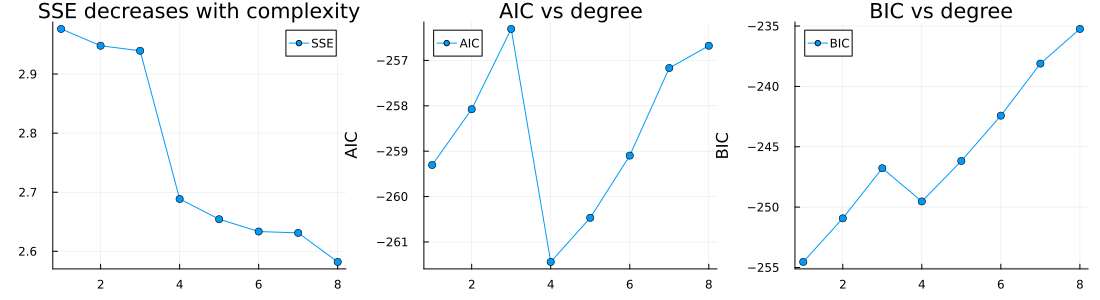

In [41]:
degrees = [r.degree for r in poly_results]
sse = [r.SSE for r in poly_results]
aic = [r.AIC for r in poly_results]
bic = [r.BIC for r in poly_results]

p1 = plot(degrees, sse; xlabel = "degree", ylabel = "SSE", marker = :circle, label = "SSE", title = "SSE decreases with complexity")
p2 = plot(degrees, aic; xlabel = "degree", ylabel = "AIC", marker = :circle, label = "AIC", title = "AIC vs degree")
p3 = plot(degrees, bic; xlabel = "degree", ylabel = "BIC", marker = :circle, label = "BIC", title = "BIC vs degree")
plot(p1, p2, p3; layout = (1,3), size = (1100, 300))

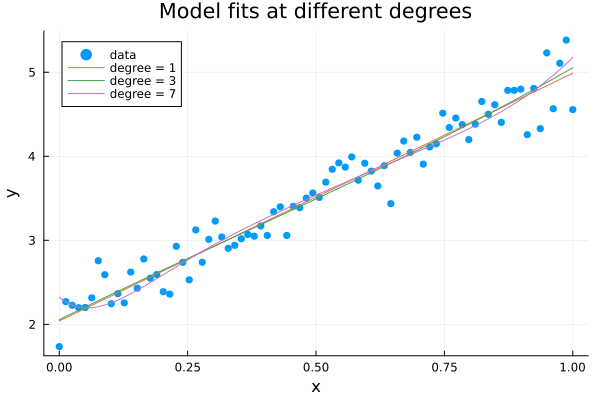

In [42]:
selected = [1, 3, 7]
plot(x_data, y_data; seriestype = :scatter, markerstrokewidth = 0, label = "data", xlabel = "x", ylabel = "y", title = "Model fits at different degrees")
for d in selected
    r = poly_results[d]
    plot!(x_data, r.y_pred; label = "degree = $(d)")
end
plot!()

AIC and BIC balance fit and parsimony: they add penalties (`2k` vs `k*log(n)`) that grow with parameter count, so the preferred model need not have the smallest SSE. SSE shrinks monotonically with degree, but AIC/BIC often reach a minimum at a modest degree (close to the true linear model) once extra terms mostly chase noise. BIC penalizes more strongly, so it typically stops adding terms earlier than AIC. This illustrates that blindly minimizing training error overfits and that information criteria formalize the trade-off.

## 2. Non-identifiable higher-order model
Use a cubic-with-product model where only the product `a*b` matters in the leading term: `f(x; a, b, c) = (a*b)*x^3 + c*x^2`. Many `(a, b)` pairs with the same product (and fixed `c`) give nearly identical fits, creating a curved valley of equivalent solutions.

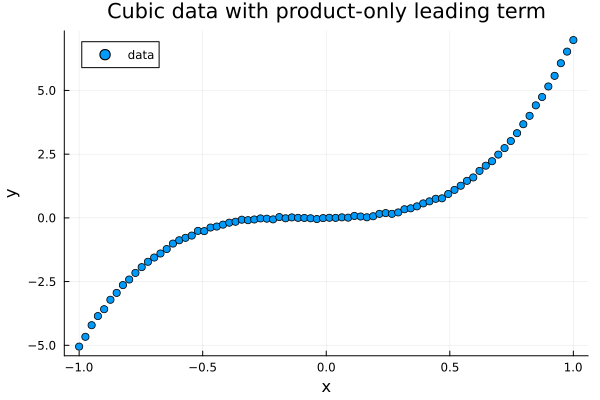

In [43]:
a_true, b_true = 2.0, 3.0
c_true = 1.0
prod_true = a_true * b_true

x2_data = collect(range(-1, 1, length = 80))
sigma2 = 0.03
y2_data = prod_true .* x2_data.^3 .+ c_true .* x2_data.^2 .+ randn(length(x2_data)) .* sigma2

scatter(x2_data, y2_data; xlabel = "x", ylabel = "y", label = "data", title = "Cubic data with product-only leading term")

### 2.1 Grid search over (a, b) and SSE heatmap
Compute SSE on a grid to reveal the flat valley of near-equivalent solutions where `a*b` is close to `prod_true`. The quadratic coefficient `c` is fixed to the true value to isolate the non-identifiable product direction.

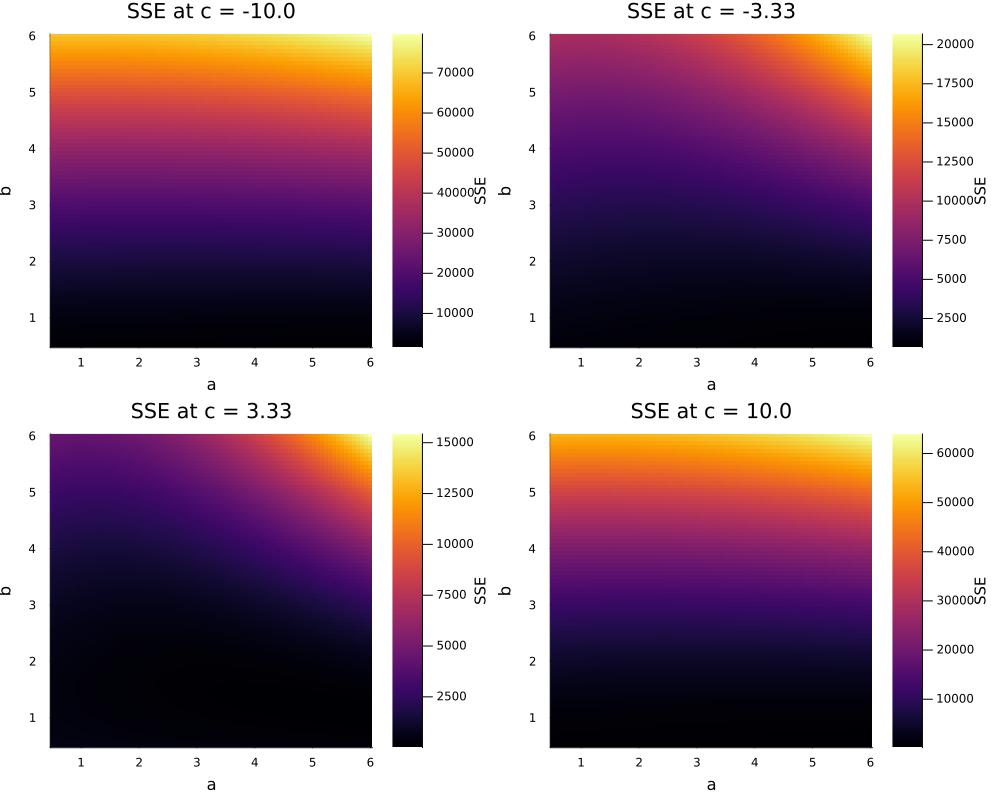

In [58]:
## 2. Non-identifiable higher-order model with moving valleys
# Model: f(x; a, b, c) = (a*b)*x^3 + (b*c)*x^2
a_true, b_true, c_true = 2.0, 3.0, 1.3
prod1_true = a_true * b_true   # cubic coefficient
prod2_true = b_true * c_true   # quadratic coefficient

x2_data = collect(range(-1, 1, length = 80))
sigma2 = 0.03
y2_data = prod1_true .* x2_data.^3 .+ prod2_true .* x2_data.^2 .+ randn(length(x2_data)) .* sigma2

scatter(x2_data, y2_data; xlabel = "x", ylabel = "y", label = "data",
        title = "Data from two interacting products")

# SSE over full (a, b, c) grid (no fitting)
function sse_abc(a, b, c, x, y)
    y_pred = (a * b) .* x.^3 .+ (b * c) .* x.^2
    sum((y .- y_pred).^2)
end

a_grid = range(0.5, 6.0, length = 80)
b_grid = range(0.5, 6.0, length = 80)
c_grid = range(-10.0, 10.0, length = 4)  # 4 slices to show valley movement

sse_tensor = [sse_abc(a, b, c, x2_data, y2_data) for a in a_grid, b in b_grid, c in c_grid]

plots = []
for (k, cval) in enumerate(c_grid)
    sse_slice = sse_tensor[:, :, k]
    push!(plots,
        heatmap(a_grid, b_grid, sse_slice';
                xlabel = "a", ylabel = "b",
                title = "SSE at c = $(round(cval, digits=2))",
                colorbar = false))
end
plot(plots...; layout = (2, 2), size = (1000, 800), colorbar = true, colorbar_title = "SSE")


### 2.2 Different (a, b) with similar fits
Pick several points along the valley and show their predictions overlap on the cubic data.

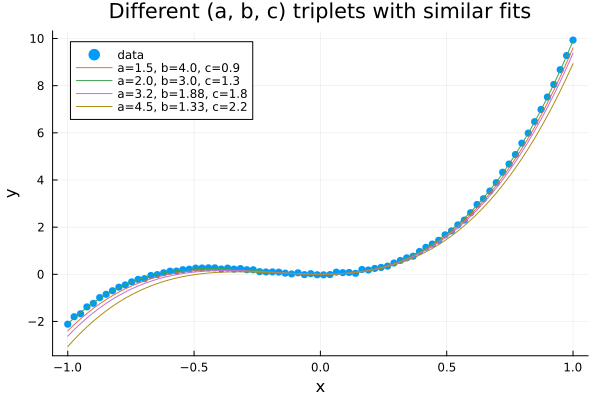

In [61]:

# Overlapping fits for a few (a,b,c) triplets along different valleys
triplets = [(1.5, prod1_true/1.5, 0.9),
            (2.0, prod1_true/2.0, 1.3),
            (3.2, prod1_true/3.2, 1.8),
            (4.5, prod1_true/4.5, 2.2)]
plot(x2_data, y2_data; seriestype = :scatter, markerstrokewidth = 0, label = "data",
     xlabel = "x", ylabel = "y", title = "Different (a, b, c) triplets with similar fits")
for (a, b, c) in triplets
    y_pred = (a * b) .* x2_data.^3 .+ (b * c) .* x2_data.^2
    plot!(x2_data, y_pred; label = "a=$(round(a, digits=2)), b=$(round(b, digits=2)), c=$(round(c, digits=2))")
end
plot!()


### 2.3 Brief summary
Only the product `a*b` in the leading cubic term is identifiable here: the SSE surface has a long, flat valley where `a*b ? $(prod_true)`, so many `(a, b)` pairs fit almost equally well when `c` is fixed. This non-uniqueness means data cannot pin down `a` and `b` separately. Flat directions like this commonly arise in multiplicative or over-parameterized models and make parameter estimation ambiguous.

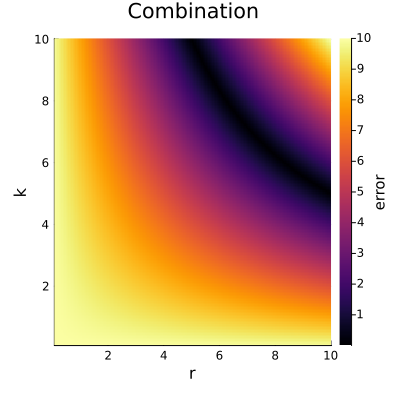

In [69]:
using Plots

############################################################
# Helper: compute |x * y * const - target| on a grid
############################################################

function product_error_grid(x_vals::AbstractVector,
                            y_vals::AbstractVector,
                            const_val::Real;
                            target::Real = 10.0)
    # Plots.heatmap expects Z[j,i] mapped to (x[i], y[j])
    Z = [abs(x * y * const_val - target) for y in y_vals, x in x_vals]
    return Z
end

############################################################
# 1) Heatmaps for a * b * c = 10, with c = 1, 2, 3
############################################################

# Ranges for a and b
a_vals = range(0.1, 10.0; length=200)
b_vals = range(0.1, 10.0; length=200)

cs = [1.0, 2.0, 3.0]

plots_abc = Any[]  # <- changed from Plot[]

for c in cs
    Z = product_error_grid(a_vals, b_vals, c; target=10.0)

    p = heatmap(
        a_vals,
        b_vals,
        Z;
        xlabel = "a",
        ylabel = "b",
        title = "|a · b · c - 10|,  c = $(c)",
        colorbar_title = "error",
    )
    push!(plots_abc, p)
end

plot(plots_abc...; layout = (1, 3), size = (1200, 400),
     title = "Non-unique (a, b) combinations for a · b · c = 10")

############################################################
# 2) Heatmaps for r * k * θ = 10, with θ = 1, 2, 3
############################################################

r_vals = range(0.1, 10.0; length=200)
k_vals = range(0.1, 10.0; length=200)

thetas = [0.2]

plots_rkθ = Any[]  # <- changed from Plot[]

for θ in thetas
    Z = product_error_grid(r_vals, k_vals, θ; target=10.0)

    p = heatmap(
        r_vals,
        k_vals,
        Z;
        xlabel = "r",
        ylabel = "k",
        title = "|r · k · θ - 10|,  θ = $(θ)",
        colorbar_title = "error",
    )
    push!(plots_rkθ, p)
end

plot(plots_rkθ...; layout = (1, 3), size = (400, 400),
     title = "Combination")
